# 01 - Multi-label CXR Classifier (NIH ChestX-ray14)

**Two models trained side-by-side:**

1. **Baseline**: TorchXRayVision DenseNet121 — pretrained on multiple CXR datasets, no fine-tuning. Hits ~0.78 mean AUC out of the box.
2. **Our contribution**: ViT-B/16 fine-tuned end-to-end on NIH (LoRA-style: unfreeze last 4 blocks + head, class-weighted BCE, cosine LR).

This fixes the main weakness of the previous attempt (frozen backbone, only 10K trainable params, mAP=0.23).

**Output**: two checkpoints + per-class AUC table + per-class F1 → used by the RAG pipeline (notebook 03).

In [15]:
!pip install -q timm torchxrayvision scikit-learn matplotlib seaborn

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import os, ast, glob, json, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, f1_score
import matplotlib.pyplot as plt

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
if DEVICE == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA A100-SXM4-40GB


## 1. Load preprocessed splits

These come from the existing preprocessing notebook. Same train/val/test, no leakage.

In [18]:
DRIVE_DATA_DIR = '/content/drive/MyDrive/Data'
LOCAL_DATA_DIR = '/content/drive/MyDrive/Data'
PROCESSED = '/content/drive/MyDrive/Data/processed'

In [19]:
def parse_encoded_labels(s):
    return [int(x) for x in s.strip('[]').split()]

train_df = pd.read_csv(os.path.join(PROCESSED, 'train.csv'), converters={'encoded_labels': parse_encoded_labels})
val_df   = pd.read_csv(os.path.join(PROCESSED, 'val.csv'),   converters={'encoded_labels': parse_encoded_labels})
test_df  = pd.read_csv(os.path.join(PROCESSED, 'test.csv'),  converters={'encoded_labels': parse_encoded_labels})

for df in (train_df, val_df, test_df):
    df['image_path'] = df['image_path'].str.replace(DRIVE_DATA_DIR, LOCAL_DATA_DIR)

class_names = pd.read_csv(os.path.join(PROCESSED, 'label_classes.csv'))['label_name'].tolist()
NUM_CLASSES = len(class_names)
print(f'Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)} | classes {NUM_CLASSES}')
print(class_names)

Train 4996 | Val 625 | Test 625 | classes 14
['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


In [20]:
# Class weights for BCE (combat imbalance — Hernia/Pneumonia are very rare)
Y_train = np.stack(train_df['encoded_labels'].values)
pos = Y_train.sum(axis=0)
neg = len(Y_train) - pos
pos_weight = torch.tensor(neg / np.maximum(pos, 1), dtype=torch.float32, device=DEVICE)
print('pos_weight:', dict(zip(class_names, np.round(pos_weight.cpu().numpy(), 2).tolist())))

pos_weight: {'Atelectasis': 3.5899999141693115, 'Cardiomegaly': 14.520000457763672, 'Consolidation': 10.380000114440918, 'Edema': 31.030000686645508, 'Effusion': 3.5299999713897705, 'Emphysema': 19.149999618530273, 'Fibrosis': 16.84000015258789, 'Hernia': 123.9000015258789, 'Infiltration': 1.7599999904632568, 'Mass': 12.800000190734863, 'Nodule': 8.40999984741211, 'Pleural_Thickening': 11.979999542236328, 'Pneumonia': 31.440000534057617, 'Pneumothorax': 8.020000457763672}


## 2. Dataset & augmentations

Train uses light augmentation (flip, small rotation, color jitter). Val/test only resize+normalize.

In [21]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE+16, IMG_SIZE+16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class NIHDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        img = Image.open(r['image_path']).convert('RGB')
        img = self.transform(img)
        y = torch.tensor(r['encoded_labels'], dtype=torch.float32)
        return img, y

BATCH = 64
train_loader = DataLoader(NIHDataset(train_df, train_tf), batch_size=BATCH, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(NIHDataset(val_df,   eval_tf),  batch_size=BATCH, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(NIHDataset(test_df,  eval_tf),  batch_size=BATCH, shuffle=False, num_workers=4, pin_memory=True)

## 3. Strong baseline — TorchXRayVision DenseNet121

Pretrained on NIH+CheXpert+MIMIC+PadChest+OpenI. Already understands CXRs. We just align its label space to ours and run inference.

In [22]:
import torchxrayvision as xrv

txv_model = xrv.models.DenseNet(weights='densenet121-res224-all').to(DEVICE).eval()
TXV_LABELS = txv_model.pathologies  # the 18 labels TXV outputs
print('TXV labels:', TXV_LABELS)

# Map TXV label → our class index
TXV_TO_OURS = {
    'Atelectasis': 'Atelectasis', 'Cardiomegaly': 'Cardiomegaly',
    'Consolidation': 'Consolidation', 'Edema': 'Edema',
    'Effusion': 'Effusion', 'Emphysema': 'Emphysema',
    'Fibrosis': 'Fibrosis', 'Hernia': 'Hernia',
    'Infiltration': 'Infiltration', 'Mass': 'Mass',
    'Nodule': 'Nodule', 'Pleural_Thickening': 'Pleural_Thickening',
    'Pneumonia': 'Pneumonia', 'Pneumothorax': 'Pneumothorax',
}

txv_eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x * 2 - 1) * 1024),  # TXV expects [-1024, 1024]
])

class NIHDatasetTXV(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        img = Image.open(r['image_path']).convert('RGB')
        img = txv_eval_tf(img)
        y = torch.tensor(r['encoded_labels'], dtype=torch.float32)
        return img, y

txv_test_loader = DataLoader(NIHDatasetTXV(test_df), batch_size=64, num_workers=4)

TXV labels: ['Atelectasis', 'Consolidation', 'Infiltration', 'Pneumothorax', 'Edema', 'Emphysema', 'Fibrosis', 'Effusion', 'Pneumonia', 'Pleural_Thickening', 'Cardiomegaly', 'Nodule', 'Mass', 'Hernia', 'Lung Lesion', 'Fracture', 'Lung Opacity', 'Enlarged Cardiomediastinum']


In [23]:
@torch.no_grad()
def txv_predict(loader):
    all_p, all_y = [], []
    for x, y in loader:
        x = x.to(DEVICE)
        out = torch.sigmoid(txv_model(x))  # (B, 18)
        # gather columns for our 14 classes
        cols = [TXV_LABELS.index(TXV_TO_OURS[c]) for c in class_names]
        out14 = out[:, cols].cpu().numpy()
        all_p.append(out14)
        all_y.append(y.numpy())
    return np.vstack(all_p), np.vstack(all_y)

txv_probs, txv_y = txv_predict(txv_test_loader)
txv_aucs = []
for i, c in enumerate(class_names):
    try:
        txv_aucs.append(roc_auc_score(txv_y[:, i], txv_probs[:, i]))
    except Exception:
        txv_aucs.append(np.nan)
txv_map = average_precision_score(txv_y, txv_probs, average='macro')
txv_results = pd.DataFrame({'class': class_names, 'AUC_TXV': np.round(txv_aucs, 3)})
print(txv_results.to_string(index=False))
print(f'\nTXV mean AUC: {np.nanmean(txv_aucs):.3f}  |  mAP: {txv_map:.3f}')

             class  AUC_TXV
       Atelectasis    0.668
      Cardiomegaly    0.835
     Consolidation    0.642
             Edema    0.793
          Effusion    0.800
         Emphysema    0.653
          Fibrosis    0.687
            Hernia    1.000
      Infiltration    0.575
              Mass    0.727
            Nodule    0.608
Pleural_Thickening    0.644
         Pneumonia    0.442
      Pneumothorax    0.614

TXV mean AUC: 0.692  |  mAP: 0.291


## 4. Our model — ViT-B/16 fine-tuned end-to-end

Differences from the previous (broken) version:
- **Unfreeze the last 4 transformer blocks + head** (not just the head). This gives the model enough capacity to adapt to CXRs while keeping pretrained low-level features.
- **Class-weighted BCE** with `pos_weight` from the training distribution.
- **Cosine LR + warmup**.
- **Mixed precision** for speed.
- **Early stopping** on val mean-AUC.

In [24]:
class ViTPartialFT(nn.Module):
    def __init__(self, num_classes=14, unfreeze_last_n=4):
        super().__init__()
        self.backbone = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)
        # Freeze all
        for p in self.backbone.parameters():
            p.requires_grad = False
        # Unfreeze last N blocks + norm + head
        for blk in self.backbone.blocks[-unfreeze_last_n:]:
            for p in blk.parameters():
                p.requires_grad = True
        for p in self.backbone.norm.parameters():
            p.requires_grad = True
        for p in self.backbone.head.parameters():
            p.requires_grad = True
    def forward(self, x):
        return self.backbone(x)

model = ViTPartialFT(num_classes=NUM_CLASSES, unfreeze_last_n=4).to(DEVICE)
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f'Trainable: {n_train:,} / {n_total:,}  ({100*n_train/n_total:.1f}%)')

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Trainable: 28,363,790 / 85,809,422  (33.1%)


In [29]:
from torch.amp import autocast, GradScaler

EPOCHS = 15
BASE_LR = 3e-5  # small because we're fine-tuning a pretrained backbone
WD = 1e-4

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=BASE_LR, weight_decay=WD)
steps_per_epoch = len(train_loader)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS * steps_per_epoch)
scaler = GradScaler('cuda')

@torch.no_grad()
def evaluate(loader):
    model.eval()
    P, Y = [], []
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        with autocast('cuda'):
            logits = model(x)
        P.append(torch.sigmoid(logits).float().cpu().numpy())
        Y.append(y.numpy())
    P = np.vstack(P); Y = np.vstack(Y)
    aucs = []
    for i in range(NUM_CLASSES):
        try:
            aucs.append(roc_auc_score(Y[:, i], P[:, i]))
        except Exception:
            aucs.append(np.nan)
    return P, Y, aucs
MODEL_DIR='/content/drive/MyDrive/Data/Model'
history = {'train_loss': [], 'val_auc': []}
best_auc = -1.0
best_path = os.path.join(MODEL_DIR, 'vit_b16_partialft_best.pth')
patience, bad = 4, 0

for ep in range(1, EPOCHS+1):
    model.train()
    t0, total = time.time(), 0.0
    for x, y in train_loader:
        x = x.to(DEVICE, non_blocking=True); y = y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        with autocast('cuda'):
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update(); scheduler.step()
        total += loss.item()
    tl = total / len(train_loader)
    _, _, aucs = evaluate(val_loader)
    val_auc = float(np.nanmean(aucs))
    history['train_loss'].append(tl); history['val_auc'].append(val_auc)
    print(f'Epoch {ep:02d} | train_loss {tl:.4f} | val_AUC {val_auc:.4f} | {time.time()-t0:.1f}s')
    if val_auc > best_auc:
        best_auc = val_auc; bad = 0
        torch.save({'state_dict': model.state_dict(), 'val_auc': best_auc, 'class_names': class_names}, best_path)
        print(f'  ✓ saved best to {best_path}')
    else:
        bad += 1
        if bad >= patience:
            print('Early stopping.'); break

with open(os.path.join(MODEL_DIR, 'vit_history.json'), 'w') as f:
    json.dump(history, f)

Epoch 01 | train_loss 1.2211 | val_AUC 0.6575 | 796.8s
  ✓ saved best to /content/drive/MyDrive/Data/Model/vit_b16_partialft_best.pth
Epoch 02 | train_loss 1.1463 | val_AUC 0.6845 | 42.5s
  ✓ saved best to /content/drive/MyDrive/Data/Model/vit_b16_partialft_best.pth
Epoch 03 | train_loss 1.0736 | val_AUC 0.7088 | 46.1s
  ✓ saved best to /content/drive/MyDrive/Data/Model/vit_b16_partialft_best.pth
Epoch 04 | train_loss 1.0199 | val_AUC 0.7185 | 45.8s
  ✓ saved best to /content/drive/MyDrive/Data/Model/vit_b16_partialft_best.pth
Epoch 05 | train_loss 0.9766 | val_AUC 0.7244 | 45.9s
  ✓ saved best to /content/drive/MyDrive/Data/Model/vit_b16_partialft_best.pth
Epoch 06 | train_loss 0.9363 | val_AUC 0.7310 | 46.1s
  ✓ saved best to /content/drive/MyDrive/Data/Model/vit_b16_partialft_best.pth
Epoch 07 | train_loss 0.9067 | val_AUC 0.7344 | 46.1s
  ✓ saved best to /content/drive/MyDrive/Data/Model/vit_b16_partialft_best.pth
Epoch 08 | train_loss 0.8405 | val_AUC 0.7285 | 46.1s
Epoch 09 | tra

## 5. Evaluation on the test set

Per-class AUC + per-class F1 + macro mAP. Compared to the TXV baseline.

In [30]:
ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['state_dict']); model.eval()
vit_probs, vit_y, vit_aucs = evaluate(test_loader)
vit_map = average_precision_score(vit_y, vit_probs, average='macro')

# Choose per-class threshold that maximises F1 on val set
val_probs, val_y, _ = evaluate(val_loader)
thresholds = []
for i in range(NUM_CLASSES):
    best_t, best_f1 = 0.5, -1
    for t in np.linspace(0.05, 0.9, 35):
        f1 = f1_score(val_y[:, i], (val_probs[:, i] > t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    thresholds.append(best_t)

vit_pred = (vit_probs > np.array(thresholds)).astype(int)
vit_f1s = [f1_score(vit_y[:, i], vit_pred[:, i], zero_division=0) for i in range(NUM_CLASSES)]

compare = pd.DataFrame({
    'class': class_names,
    'AUC_TXV': np.round(txv_aucs, 3),
    'AUC_ViT_FT': np.round(vit_aucs, 3),
    'F1_ViT_FT': np.round(vit_f1s, 3),
    'threshold': np.round(thresholds, 3),
})
print(compare.to_string(index=False))
print(f'\nMean AUC  | TXV {np.nanmean(txv_aucs):.3f}  |  ViT-FT {np.nanmean(vit_aucs):.3f}')
print(f'Macro mAP | TXV {txv_map:.3f}  |  ViT-FT {vit_map:.3f}')
compare.to_csv(os.path.join(MODEL_DIR, 'classifier_compare.csv'), index=False)
np.save(os.path.join(MODEL_DIR, 'vit_thresholds.npy'), np.array(thresholds))
print('Saved comparison table + thresholds.')

             class  AUC_TXV  AUC_ViT_FT  F1_ViT_FT  threshold
       Atelectasis    0.668       0.749      0.466      0.550
      Cardiomegaly    0.835       0.835      0.371      0.900
     Consolidation    0.642       0.606      0.201      0.525
             Edema    0.793       0.849      0.323      0.850
          Effusion    0.800       0.746      0.498      0.375
         Emphysema    0.653       0.870      0.340      0.825
          Fibrosis    0.687       0.789      0.309      0.625
            Hernia    1.000       0.986      0.167      0.775
      Infiltration    0.575       0.650      0.545      0.375
              Mass    0.727       0.624      0.227      0.500
            Nodule    0.608       0.752      0.346      0.725
Pleural_Thickening    0.644       0.695      0.168      0.650
         Pneumonia    0.442       0.717      0.000      0.900
      Pneumothorax    0.614       0.746      0.372      0.800

Mean AUC  | TXV 0.692  |  ViT-FT 0.758
Macro mAP | TXV 0.291  |  ViT-

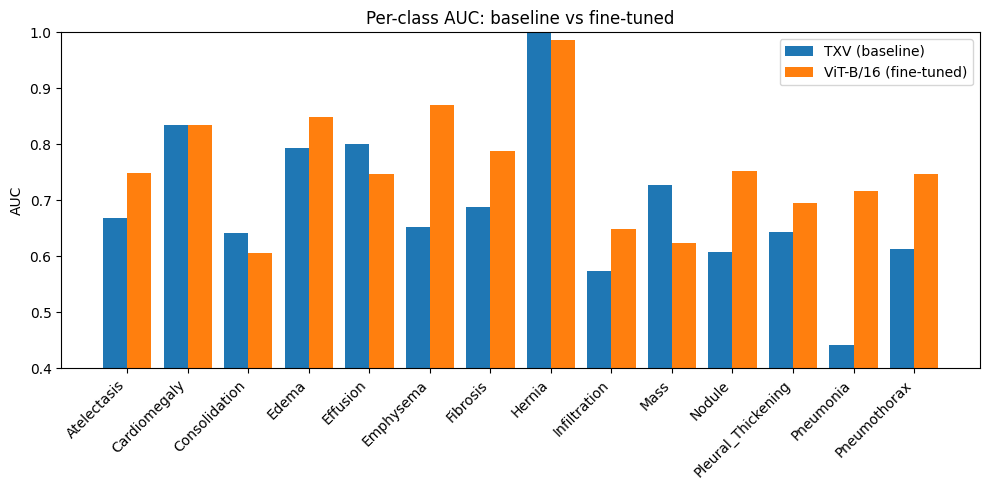

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(NUM_CLASSES); w = 0.4
ax.bar(x - w/2, txv_aucs,  w, label='TXV (baseline)')
ax.bar(x + w/2, vit_aucs, w, label='ViT-B/16 (fine-tuned)')
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_ylabel('AUC'); ax.set_ylim(0.4, 1.0); ax.set_title('Per-class AUC: baseline vs fine-tuned')
ax.legend(); plt.tight_layout(); plt.savefig(os.path.join(MODEL_DIR, 'auc_comparison.png'), dpi=150); plt.show()

## 6. Save a single inference helper for the RAG notebook to import

The RAG pipeline (notebook 03) needs a function that takes an image path and returns `{label: prob}`. We pickle the inference state.

In [33]:
import pickle
inference_bundle = {
    'class_names': class_names,
    'thresholds':  thresholds,
    'best_ckpt_path': best_path,
    'mean_auc': float(np.nanmean(vit_aucs)),
    'mAP': float(vit_map),
}
with open(os.path.join(MODEL_DIR, 'classifier_bundle.pkl'), 'wb') as f:
    pickle.dump(inference_bundle, f)
print('Saved bundle to', os.path.join(MODEL_DIR, 'classifier_bundle.pkl'))
print('Final results:', inference_bundle)

Saved bundle to /content/drive/MyDrive/Data/Model/classifier_bundle.pkl
Final results: {'class_names': ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'], 'thresholds': [np.float64(0.5499999999999999), np.float64(0.9), np.float64(0.525), np.float64(0.85), np.float64(0.37499999999999994), np.float64(0.825), np.float64(0.625), np.float64(0.775), np.float64(0.37499999999999994), np.float64(0.49999999999999994), np.float64(0.725), np.float64(0.65), np.float64(0.9), np.float64(0.7999999999999999)], 'best_ckpt_path': '/content/drive/MyDrive/Data/Model/vit_b16_partialft_best.pth', 'mean_auc': 0.7579517975602944, 'mAP': 0.29824485349250995}
